# EX09: Data Analysis for Continuous Improvement

In this exercise, you and your partner will be defining functions for data analysis, using those functions to analyze the data from the anonymized survey you took not long ago, and then presenting your analysis via a live website! Your project will need to satisfy many specifications so be sure to read the entire write-up and this template notebook thoroughly before beginning any programming.

In [ ]:
__author__ = ["730886707", "730862636"] # Record you and your partner's PIDs here!

### IMPORTANT SETUP STEP

To ensure the correct version of python is being used while you are running this Jupyter notebook, please first make sure you are in the dev container (the bottom left corner should say Dev Container). Then, click on the kernel selection button (the rightmost button at the top of this file), it may currently say "Select Kernel", "Python 3.12.4", or something similar. 

If your kernel selection button says "Select Kernel", after clicking on it there should be two options: "Python Environments..." and "Existing Jupyter Server...". Choose "Python Environments...", then there should be two options (but possibly more will show up): "Python 3.12.4 `/usr/local/bin/python`" and "Python 3.12.4 `/usr/bin/python3`". Please select the first of these two options, and if any others are present do not select them. 

If your kernel selection button says anything besides "Select Kernel", after clicking on it it will tell you which you have currently selected. If it is not the "Python 3.12.4 `/usr/local/bin/python`" option, choose "Select Another Kernel..." and then follow the previous paragraph's instructions. If your kernel selection menu does not include the necessary options to follow these instructions, please come to office hours.

## Part 0: Data Utilities

You will define and use functions that are commonly useful when _wrangling_ data in this exercise. You will frequently need your data to be organized in specific ways in order to perform analysis on it and that organization is rarely exactly the "shape" the data is stored in (such as a CSV table). Data _wrangling_ is the process of loading, converting, and reorganizing data so that you can analyze it.

You will implement the utility functions for this exercise in the `data_utils.py` file found in the `exercises/ex09` directory. As you now know, when you import modules in a running Python program, the module is evaluated only once. Since your Jupyter Notebook _kernel_ is running the entire time you are working on functions in `data_utils.py`, we will use a special extension to automatically reload any changes you make _and save_ in modules you import. The special conventions in the cell below are turning this feature on.

In [21]:
%reload_ext autoreload
%autoreload 2
print("Autoreload of imported modules enabled. Be sure to save your work in other modules!")

Autoreload of imported modules enabled. Be sure to save your work in other modules!


The data files you will use in this exercise, `survey_izzi.csv` and `survey_alyssa.csv`, are located in the `exercises/ex09/data` directory. We will establish a constant to hold these filenames for later.

Each row represents an individual survey response. Each column has a description which can be found on the project write-up here: <https://26s-comp110.github.io/exercises/ex09_data_analysis.html>

In [22]:
DATA_FILE_DIRECTORY: str = "data/"
DATA_FILE_NAMES: list[str] = ["survey_izzi.csv", "survey_alyssa.csv"]
DATA_FILE_NAME_IZZI: str = f"{DATA_FILE_DIRECTORY}{DATA_FILE_NAMES[0]}"
DATA_FILE_NAME_ALYSSA: str = f"{DATA_FILE_DIRECTORY}{DATA_FILE_NAMES[1]}"

### Part 0.0: Data Reading Functions

You will begin your journey into data wrangling by importing and testing the functions given to you in class!  Copy the functions for reading data from a csv (`read_csv_rows`, `column_values`, and `columnar`) into `data_utils.py`. Be sure to save your changes in that file _before_ evaluating the cells below. Now let's try them!

#### `read_csv_rows`

Purpose: Read an entire CSV of data into a `list` of rows, each row represented as `dict[str, str]`.

* Function Name: `read_csv_rows`
* Parameter: 
    1. `str` path to CSV file
* Return Type: `list[dict[str, str]]` 


In [23]:
from data_utils import read_csv_rows, get_keys
data_rows: list[dict[str, str]] = read_csv_rows(DATA_FILE_NAME_IZZI)

if len(data_rows) == 0:
    print("Go implement read_csv_rows in data_utils.py")
    print("Be sure to save your work before re-evaluating this cell!")
else:
    print(f"Data File Read: {DATA_FILE_NAME_IZZI}")
    print(f"{len(data_rows)} rows")
    print(f"{len(get_keys(data_rows[0]))} columns")
    print(f"Columns names: {get_keys(data_rows[0])}")

Data File Read: data/survey_izzi.csv
534 rows
44 columns
Columns names: ['row', 'year', 'unc_status', 'transfer', 'comp_major', 'major', 'prereqs', 'prior_exp', 'ap_principles', 'ap_a', 'other_comp', 'prior_time', 'languages', 'hours_online_social', 'hours_online_work', 'tech_best_interests', 'apps_accessible', 'identity_my_interaction', 'id_interact_with_me', 'interested_connections', 'social_issues', 'research_biases', 'researchers_unbiased', 'empirical_data', 'cs_objective', 'algorithms_objective', 'tech_impact', 'pre_lecture_videos', 'add_livestream', 'own_notes', 'own_examples', 'oh_visits', 'ls_effective', 'lsqs_effective', 'programming_effective', 'qz_effective', 'oh_effective', 'tutoring_effective', 'pace', 'difficulty', 'understanding', 'interesting', 'valuable', 'would_recommend']


#### `column_values`

Purpose: Produce a `list[str]` of all values in a single `column` whose name is the second parameter.

* Function Name: `column_values`
* Parameters: 
    1. `list[dict[str, str]]` - a list of rows representing a _table_
    2. `str` - the name of the column (key) whose values are being selected
* Return Type: `list[str]`

In [24]:
from data_utils import column_values

years: list[str] = column_values(data_rows, "year")

if len(years) == 0:
    print("Complete your implementation of column_values in data_utils.py")
    print("Be sure to follow the guidelines above and save your work before re-evaluating!")
else:
    print(f"Column 'year' has {len(years)} values.")
    print("The first five values are:")
    for i in range(5):
        print(years[i])

Column 'year' has 534 values.
The first five values are:
27
28
29
28
28


#### `columnar`

Purpose: _Transform_ a table represented as a list of rows (e.g. `list[dict[str, str]]`) into one represented as a dictionary of columns (e.g. `dict[str, list[str]]`).

Why is this function useful? Many types of analysis are much easier to perform column-wise.

* Function Name: `columnar`
* Parameter: `list[dict[str, str]]` - a "table" organized as a list of rows
* Return Type: `dict[str, list[str]]` - a "table" organized as a dictionary of columns

In [6]:
from data_utils import columnar

data_cols: dict[str, list[str]] = columnar(data_rows)

if len(get_keys(data_cols)) == 0:
    print("Complete your implementation of columnar in data_utils.py")
    print("Be sure to follow the guidelines above and save your work before re-evaluating!")
else:
    print(f"{len(get_keys(data_cols))} columns")
    print(f"{len(data_cols['year'])} rows")
    print(f"Columns names: {get_keys(data_cols)}")

44 columns
534 rows
Columns names: ['row', 'year', 'unc_status', 'transfer', 'comp_major', 'major', 'prereqs', 'prior_exp', 'ap_principles', 'ap_a', 'other_comp', 'prior_time', 'languages', 'hours_online_social', 'hours_online_work', 'tech_best_interests', 'apps_accessible', 'identity_my_interaction', 'id_interact_with_me', 'interested_connections', 'social_issues', 'research_biases', 'researchers_unbiased', 'empirical_data', 'cs_objective', 'algorithms_objective', 'tech_impact', 'pre_lecture_videos', 'add_livestream', 'own_notes', 'own_examples', 'oh_visits', 'ls_effective', 'lsqs_effective', 'programming_effective', 'qz_effective', 'oh_effective', 'tutoring_effective', 'pace', 'difficulty', 'understanding', 'interesting', 'valuable', 'would_recommend']


### Part 0.1: Selecting ("narrowing down") a Data Table

When working with a data set, it is useful to inspect the contents of the table you are working with in order to both be convinced your analysis is on the correct path and to know what steps to take next with specific column names or values.

In this part of the exercise, you will write some useful utility functions to view the first `N` rows of a column-based table (a function named `head`, referring to the top rows of a table) and another function `select` for producing a simpler data table with only the subset of original columns you care about.

#### Displaying Tabular data with the `tabulate` 3rd Party Library

Reading Python's `str` representations of tabular data, in either representation strategy we used above (list of rows vs. dict of cols), is uncomprehensible for data wrangling. This kind of problem is so common a 3rd party library called `tabulate` is commonly used to produce tables in Jupyter Notebooks. To install this library, run the command `python -m pip install tabulate` in the terminal (Note: if your dev container is reset and tabulate is no longer importing properly then you will need to rerun this command).

For a quick demonstration of how the `tabulate` library works, consider this simple demo below. You should be able to evaluate it as is without any further changes and see the tabular representation appear.

In [25]:
from tabulate import tabulate

universities: dict[str, list[str]] = {"school": ["UNC", "NCSU", "Duke"], "mascot": ["Rameses", "Wolf", "A Literal Devil"], "founded": ["1789", "1887", "1838"]}

tabulate(universities, get_keys(universities), "html")

school,mascot,founded
UNC,Rameses,1789
NCSU,Wolf,1887
Duke,A Literal Devil,1838


#### `head`

Define and implement this function in `data_utils.py`.

Purpose: Produce a new column-based (e.g. `dict[str, list[str]]`) table with only the first `N` (a parameter) rows of data for each column.

Why: Visualizing a table with hundreds, thousands, or millions of rows in it is overwhelming. You frequently want to just see the first few rows of a table to get a sense you are on the correct path.

* Function name: `head`
* Parameters:
    1. `dict[str, list[str]]` - a column-based table of data that _will not be mutated_
    2. `int` - The number of "rows" to include in the resulting list
* Return type: `dict[str, list[str]]`

Implementation strategy: 

1. Establish an empty dictionary that will serve as the returned dictionary this function is building up. 
2. Loop through each of the columns in the first row of the table given as a parameter. 
    1. Inside of the loop, establish an empty list to store each of the first N values in the column. 
    2. Loop through the first N items of the table's column, 
        1. Appending each item to the previously list established in step 2.1. 
    3. Assign the produced list of column values to the dictionary established in step 1.
3. Return the dictionary.

Once you have correctly implemented this function and saved your work, you should be able to evaluate the cell below and see the first five rows of the data table presented.

In [26]:
from data_utils import head

data_cols_head: dict[str, list[str]] = head(data_cols, 5)

if len(get_keys(data_cols_head)) != len(get_keys(data_cols)) or len(data_cols_head["year"]) != 5:
    print("Complete your implementation of columnar in data_utils.py")
    print("Be sure to follow the guidelines above and save your work before re-evaluating!")

tabulate(data_cols_head, get_keys(data_cols_head), "html")

row,year,unc_status,transfer,comp_major,major,prereqs,prior_exp,ap_principles,ap_a,other_comp,prior_time,languages,hours_online_social,hours_online_work,tech_best_interests,apps_accessible,identity_my_interaction,id_interact_with_me,interested_connections,social_issues,research_biases,researchers_unbiased,empirical_data,cs_objective,algorithms_objective,tech_impact,pre_lecture_videos,add_livestream,own_notes,own_examples,oh_visits,ls_effective,lsqs_effective,programming_effective,qz_effective,oh_effective,tutoring_effective,pace,difficulty,understanding,interesting,valuable,would_recommend
1,27,Senior,No,No,Chemistry,"MATH 231, MATH 232, MATH 233, STOR 155",None to less than one month!,,,,,,3 to 5 hours,5 to 10 hours,5,6,3,5,4,5,6,3,4,5,5,5,3,5,7,5,0,4,5,6,7,4,4,4,4,5,5,4,6
2,28,Sophomore,Yes,No,Economics,"MATH 232, MATH 233",2-6 months,No,No,Another college or community college,None to less than one month!,Python,0 to 2 hours,3 to 5 hours,4,5,7,7,6,7,7,6,4,6,5,4,7,6,5,7,0,5,4,7,7,,,4,4,5,7,7,7
3,29,Freshman,No,No,Statistics and Analytics,MATH 231,None to less than one month!,,,,,,3 to 5 hours,0 to 2 hours,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,3,4,4,4,4,4,4,4,4,5,4,4,4
4,28,Sophomore,No,No,Psychology,"MATH 231, MATH 232, PSYC 210, STOR 155",None to less than one month!,,,,,,0 to 2 hours,0 to 2 hours,4,4,2,2,3,3,3,3,4,4,4,4,1,2,4,5,3,5,5,5,5,,,4,4,4,3,5,5
5,28,Sophomore,No,No,Environmental Science/Studies,"MATH 129P, MATH 231, MATH 232, STOR 155",None to less than one month!,,,,,,5 to 10 hours,5 to 10 hours,4,6,3,2,3,5,4,3,4,5,6,4,2,3,4,2,0,2,6,6,6,,,5,4,6,5,4,5


#### `select`

Define and implement this function in `data_utils.py`.

Purpose: Produce a new column-based (e.g. `dict[str, list[str]]`) table with only a specific subset of the original columns.

Why: Many data tables will contain many columns that are not related to the analysis you are trying to perform. _Selecting_ only the columns you care about makes it easier to focus your attention on the problem at hand.

* Function Name: `select`
* Parameters:
    1. `dict[str, list[str]]` - a column-based table of data that _will not be mutated_
    2. `list[str]` - the names of the columns to copy to the new, returned dictionary
* Return type: `dict[str, list[str]]`

Implementation strategy:

1. Establish an empty dictionary that will serve as the returned dictionary this function is building up.
2. Loop through each of the columns _in the second parameter of the function_
    1. Assign to the column key of the result dictionary the list of values stored in the input dictionary at the same column
3. Return the dictionary produced

Once you have correctly implemented this function, you can run the cell below to visualize the first 10 rows of the table and should only see 2 columns: `year`, `major`.

In [27]:
from data_utils import select

selected_data: dict[str, list[str]] = select(data_cols, ["year", "major"])

tabulate(head(selected_data, 10), get_keys(selected_data), "html")

year,major
27,Chemistry
28,Economics
29,Statistics and Analytics
28,Psychology
28,Environmental Science/Studies
28,Business
28,Environmental Science/Studies
28,Neuroscience
29,Mathematics
28,Environmental Science/Studies


#### `concat`

Define and implement this function in `data_utils.py`.

Purpose: Produce a new column-based (e.g. `dict[str, list[str]]`) table with two column-based tables combined.

Why: You will often have data from different sources that you may wish to combine in some way to perform an analysis

* Function Name: `concat`
* Parameters:
    1. Two `dict[str, list[str]]` - a column-based tables of data that _will not be mutated_
* Return type: `dict[str, list[str]]`

Implementation strategy:

1. Establish an empty dictionary that will serve as the returned dictionary this function is building up.
2. Loop through each of the columns _in the first parameter of the function_
    1. Assign to the column key of the result dictionary the list of values stored in the first parameter at the same column
3. Loop through each of the columns _in the second parameter of the function_
    1. If the current column key is already in the result dictionary, add on the list of values stored in the second parameter at the same column 
    2. Otherwise, just assign to the column key of the result dictionary the list of values stored in the second parameter at the same column
4. Return the dictionary produced

Once you have correctly implemented this function, you can run the cell below to see 

In [28]:
from data_utils import concat

additional_table: dict[str, list[str]] = columnar(read_csv_rows(DATA_FILE_NAME_ALYSSA))

combined: dict[str, list[str]] = concat(data_cols_head, additional_table)

tabulate(head(combined, 10), get_keys(combined), "html")

row,year,unc_status,transfer,comp_major,major,prereqs,prior_exp,ap_principles,ap_a,other_comp,prior_time,languages,hours_online_social,hours_online_work,tech_best_interests,apps_accessible,identity_my_interaction,id_interact_with_me,interested_connections,social_issues,research_biases,researchers_unbiased,empirical_data,cs_objective,algorithms_objective,tech_impact,pre_lecture_videos,add_livestream,own_notes,own_examples,oh_visits,ls_effective,lsqs_effective,programming_effective,qz_effective,oh_effective,tutoring_effective,pace,difficulty,understanding,interesting,valuable,would_recommend
1,27,Senior,No,No,Chemistry,"MATH 231, MATH 232, MATH 233, STOR 155",None to less than one month!,,,,,,3 to 5 hours,5 to 10 hours,5,6,3,5,4,5,6,3,4,5,5,5,3,5,7,5,0,4,5,6,7,4,4,4,4,5,5,4,6
2,28,Sophomore,Yes,No,Economics,"MATH 232, MATH 233",2-6 months,No,No,Another college or community college,None to less than one month!,Python,0 to 2 hours,3 to 5 hours,4,5,7,7,6,7,7,6,4,6,5,4,7,6,5,7,0,5,4,7,7,,,4,4,5,7,7,7
3,29,Freshman,No,No,Statistics and Analytics,MATH 231,None to less than one month!,,,,,,3 to 5 hours,0 to 2 hours,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,3,4,4,4,4,4,4,4,4,5,4,4,4
4,28,Sophomore,No,No,Psychology,"MATH 231, MATH 232, PSYC 210, STOR 155",None to less than one month!,,,,,,0 to 2 hours,0 to 2 hours,4,4,2,2,3,3,3,3,4,4,4,4,1,2,4,5,3,5,5,5,5,,,4,4,4,3,5,5
5,28,Sophomore,No,No,Environmental Science/Studies,"MATH 129P, MATH 231, MATH 232, STOR 155",None to less than one month!,,,,,,5 to 10 hours,5 to 10 hours,4,6,3,2,3,5,4,3,4,5,6,4,2,3,4,2,0,2,6,6,6,,,5,4,6,5,4,5
1,28,Junior,No,No,Applied Physical Sciences,"MATH 129P, MATH 130, MATH 231, MATH 232, MATH 233, MATH 381",1-2 years,Yes,No,UNC,None to less than one month!,"Python, R / Matlab / SAS",3 to 5 hours,3 to 5 hours,4,3,5,6,6,7,6,6,2,4,6,6,3,2,7,5,1,7,7,7,7,,,4,3,6,6,6,7
2,28,Junior,No,No,Applied Sciences,"MATH 129P, MATH 231, MATH 232, MATH 233, MATH 381, STOR 155",1-2 years,No,No,High school course (IB or other),None to less than one month!,"Python, R / Matlab / SAS",3 to 5 hours,3 to 5 hours,5,6,6,6,5,7,7,3,3,3,3,5,3,5,7,5,0,4,7,7,4,,,4,1,6,6,6,6
3,28,Sophomore,No,No,Biology,"MATH 231, MATH 232, MATH 233, STOR 155",None to less than one month!,,,,,,3 to 5 hours,0 to 2 hours,6,6,5,5,5,6,6,6,5,6,6,6,5,5,6,6,1,5,6,6,6,,,4,3,6,5,6,6
4,28,Sophomore,No,No,Biology,"MATH 130, MATH 231, STOR 155",None to less than one month!,,,,,,5 to 10 hours,5 to 10 hours,6,7,7,7,3,7,7,7,6,7,6,6,7,7,6,6,2,5,5,4,6,,6,6,6,3,5,6,3
5,28,Senior,No,No,Biology,"MATH 129P, MATH 231, MATH 232, MATH 233",None to less than one month!,,,,,,10+ hours,5 to 10 hours,1,7,7,7,7,7,7,6,4,5,5,5,4,6,5,3,0,4,5,5,1,,,2,3,5,4,5,6


### Part 0.2: Simple Analysis

Now that you have some functions to read, transform, and select your data, let's perform some simple analysis! With categorical data, _counting_ the frequency of values is a common first step toward getting an overview of the column.

#### `count`

Given a `list[str]`, this function will produce a `dict[str, int]` where each key is a unique value in the given list and each value associated is the _count_ of the number of times that value appeared in the input list.

* Function name: `count`
* Parameter: `list[str]` - list of values to count the frequencies of
* Return Type: `dict[str, int]` - a dictionary of the counts of each of the items in the input list

Implementation strategy:

1. Establish an empty dictionary to store your built-up result in
2. Loop through each item in the input list
    1. Check to see if that item has already been established as a key in your dictionary. Try the following boolean conditional: `if <item> in <dict>:` -- replacing `<item>` with the variable name of the current value and `<dict>` with the name of your result dictionary.
    2. If the item is found in the dict, that means there is already a key/value pair where the item is a key. Increase the value associated with that key by 1 (counting it!)
    3. If the item is not found in the dict, that means this is the first time you are encountering the value and should assign an initial count of `1` to that key in the result dictionary.
3. Return the resulting dictionary.

In [29]:
from data_utils import count

year_counts: dict[str, int] = count(selected_data["year"])
print(f"year_counts: {year_counts}")

major_counts: dict[str, int] = count(selected_data["major"])
print(f"major_counts: {major_counts}")

year_counts: {'27': 100, '28': 237, '29': 149, '26': 48}
major_counts: {'Chemistry': 10, 'Economics': 67, 'Statistics and Analytics': 23, 'Psychology': 39, 'Environmental Science/Studies': 25, 'Business': 39, 'Neuroscience': 88, 'Mathematics': 21, 'Information Science': 11, 'Data Science': 40, 'Media and Journalism': 4, 'Biology': 84, 'Earth Science': 3, 'Biostatistics': 1, 'Environmental Health Sciences': 5, 'Nursing': 1, 'Political Science': 6, 'Applied Sciences': 14, 'Computer Science': 5, 'English': 1, 'Medical Anthropology': 1, 'Exercise and Sports Science': 9, 'HPM': 3, 'Peace, War, and Defense': 1, 'Advertising and PR': 4, 'Health Policy and Management': 1, 'Human Development and Family Science': 1, 'Physics': 6, 'Studio Art': 1, 'Biomedical Engineering': 4, 'Communications': 2, 'Asian Studies': 1, 'Nutrition': 2, 'Sports Administration': 2, 'Public Policy': 2, 'Undecided': 2, 'Geology': 1, 'Management and Society': 1, 'N/A': 1, 'Dramatic Art': 1, 'Interdisciplinary Studies': 1}

### Part 0.3: Python Packages, Intro to Seaborn, and Revisiting Union Types

It is now time to give you the last few tools you will need before beginning your analysis.

Python has a rich ecosystem of many *packages* or *libraries* that enable you to use code that other people write and maintain to perform a wide array of tasks like data analysis, scientific computing, or even creating a game! For this exercise you will be working with a package called `seaborn` that can be used to visualize data in a variety of ways.

One of the most valuable skills you can have as a programmer is the ability to use documentation to learn how to use code written by other people. To this end, we will be introducing you to the basics of how to use the `seaborn` package, then guiding you to the documentation that shows you how to create the visuals **you** want to create.

Let's start with how to create a basic scatterplot using the same kind of column-wise data that comes out of `columnar`.

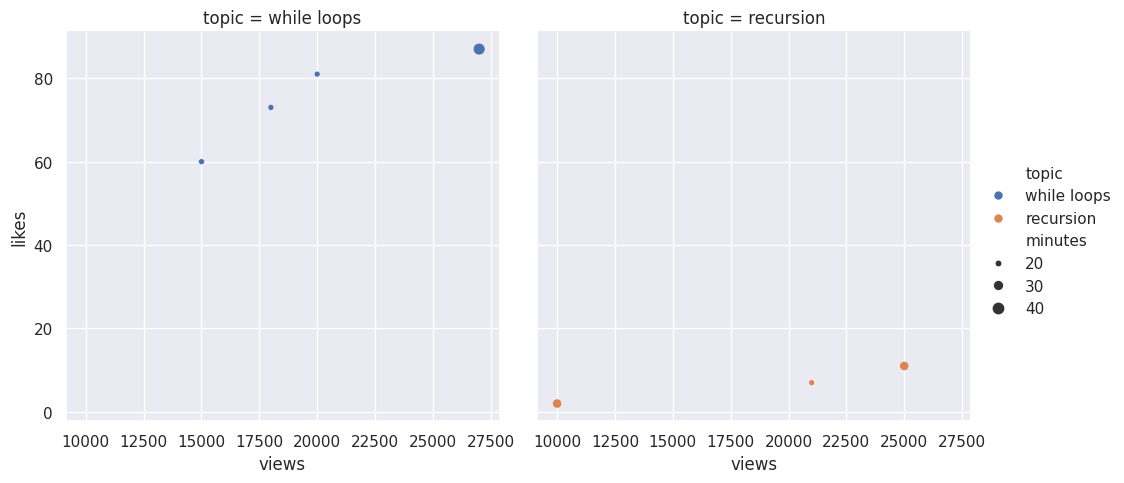

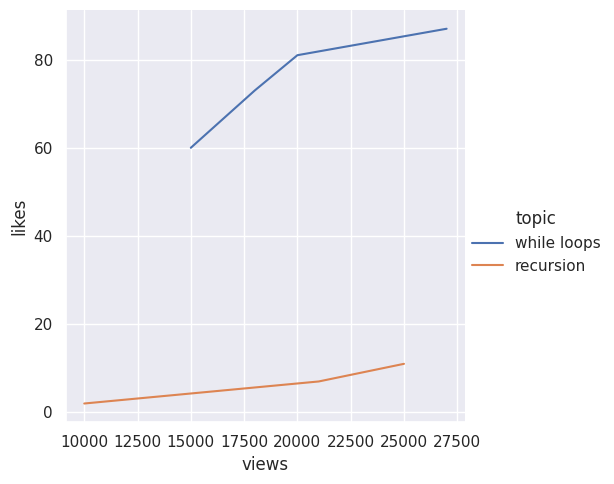

In [30]:
import seaborn as sns
from data_utils import convert_columns_to_int

sns.set_theme()

example_data: dict[str, list[str]] = {"minutes": ["20", "20", "30", "20", "20", "30", "40"], 
                                      "views": ["15000", "20000", "10000", "18000", "21000", "25000", "27000"], 
                                      "likes": ["60", "81", "2", "73", "7", "11", "87"],
                                      "topic": ["while loops", "while loops", "recursion", "while loops", "recursion", "recursion", "while loops"]}

example_data_converted: dict[str, list[str | int]] = convert_columns_to_int(example_data, ["minutes", "views", "likes"])

sns.relplot(data=example_data_converted, kind="scatter",
            x="views", y="likes", size="minutes", 
            col="topic", hue="topic")

sns.relplot(data=example_data_converted, kind="line", 
            x="views", y="likes", 
            hue="topic")

Let's go through this line-by-line.

`import seaborn as sns`

First, we import the `seaborn` package, using the `as` keyword to give it a quicker nickname `sns`. This will enable us to use any classes or functions defined in the `seaborn` package by using the prefix `sns.` and then our desired function or class name. This will look like we are calling methods with `sns` as our object, which is technically true, but think of `sns` as a module with a whole bunch of code in it that we are using bits of, not as an object with attributes that you are looking to access and modify.

`sns.set_theme()`

Then we call the `set_theme` function with no argument to give all of the plots we will create the default theme. There are [more themes](https://seaborn.pydata.org/tutorial/aesthetics.html#seaborn-figure-styles) available!

`example_data: dict[str, list[str]] = ...`

Now we create some example data to plot, with the exact same types and shape as the column-wise data that comes out of `columnar`.

`example_data_converted: dict[str, list[str | int]] = ...`

Then we use the provided starter function `convert_columns_to_int` to convert some of our columns to have the data type `int`, storing the result in a dictionary with keys of type `str` and values of type `list[str | int]`. This type that uses `|` is the same concept as what was used in class for representing a linked list (a `Node` having a `next` attribute of type `Node | None`). This means that the values of this dictionary are lists with each value in the list being of type `str` or `int`. Union types are especially useful when handling data of mixed types, which is true of the survey data you are working with (e.g. Majors are `str`s, Likert data (responses on a scale of 1-7) is of type `int`). Another starter function, `get_keys` also uses Union types to handle a wide variety of inputs. Its input is of type `dict[str, list[str]] | dict[str, list[int]] | dict[str, list[str]] | dict[str, list[str | int]] | dict[str, int] | dict[str, str]` to handle the different possibilities of what the value's type could be for various shapes (e.g. row-based, column-based) of data that we give to this function. Please note that `head`, `select`, `concat`, and `count` don't accept Union types as input, so try to only use the `convert_columns_to_int` as a last step before you make a plot. It is totally fine if your custom function(s) take Union types as input though!

Now on the final two lines we plot, first a scatterplot, then a line plot, using the `relplot` function with a few different parameters to customize our figure each time. 
- `data` - This is where you input your data dictionary.
- `kind` - Customizes the kind of plot you'll get from `relplot`. Possible values: "scatter", "line"
- `x`, `y` - Use these to define the data that will be on your x and y axes, using your column names as the arguments.
- `size` (Optional) - Use this to define the size of your dots for the scatterplot or the width of the lines for the lineplot relative to a column's data, using the column's name as the argument.
- `col` (Optional) - Use this to split your figure into multiple plots based on the values in a column, using the column's name as the argument.
- `hue` (Optional) - Use this to define the color of your dots or lines for the lineplot relative to a column's data, using the column's name as the argument.

#### Further Exploration

Seaborn uses a hierarchical structure for its plotting functions, for example `scatterplot` and `lineplot` are contained under `relplot`, or relational plot, like we just saw. The `kind` parameter is used to select which type of plot you would like. The other two overarching functions are `displot` for distribution plots and `catplot` for categorical plots. See the relevant documentation [here](https://seaborn.pydata.org/tutorial/function_overview.html#figure-level-vs-axes-level-functions) for a visual of what kind of plots are contained within each category.

Now it is time for you to explore the documentation further. These pages will contain a lot of information, and it is important to remember that they are intended to be comprehensive, but you do not have to use all of the possible features and parameters!
- `relplot` [link](https://seaborn.pydata.org/generated/seaborn.relplot.html)
- `displot` [link](https://seaborn.pydata.org/generated/seaborn.displot.html)
- `catplot` [link](http://seaborn.pydata.org/generated/seaborn.catplot.html)

As was mentioned in the rubric, you will be expected to create at least three visualizations of your data using `seaborn`, with at least one of them being outside of the two example plots shown previously. Use the documentation links above to find out what other types of plot(s) you would like to make!

While brainstorming and considering what ideas you have the data for, begin to consider what kind of visualizations would work best to support your analysis, and come back to these documentation links when you are ready to make some plots. Outside of these links, you are free to explore all of the functions and objects available in the `seaborn` package at this link: https://seaborn.pydata.org/api.html

#### Optional Customization

*Read this section if you are interested in further customizing your figures, but feel free to skip to Part 1!*

If you are curious about the object returned by these plotting functions, `sns.FacetGrid`, look here: [docs link](https://seaborn.pydata.org/generated/seaborn.FacetGrid.html). This documentation page begins by showing all of the possible parameters for its `__init__` method, then some examples of its usage, and finally its methods and attributes. `seaborn` does most of the customization for you so it is optional but encouraged to explore these methods and attributes.

If you read any of the provided documentation pages thoroughly enough, you may start to see mentions of another library called `matplotlib`, such as the methods and attributes of `sns.FacetGrid`. `seaborn` is based on `matplotlib`, and it offers more customization options but is more complex to use than `seaborn`. Certain properties you might expect of a `sns.FacetGrid` object have to work with underlying `matplotlib` objects and attributes to be set, such as creating a title for your figure (see the example below). Attributes like title that have to be accessed in this way are listed [here](https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.html#matplotlib.axes.Axes:~:text=and%20False%20otherwise.-,**kwargs,-Other%20optional%20keyword) in the documentation for `matplotlib`.

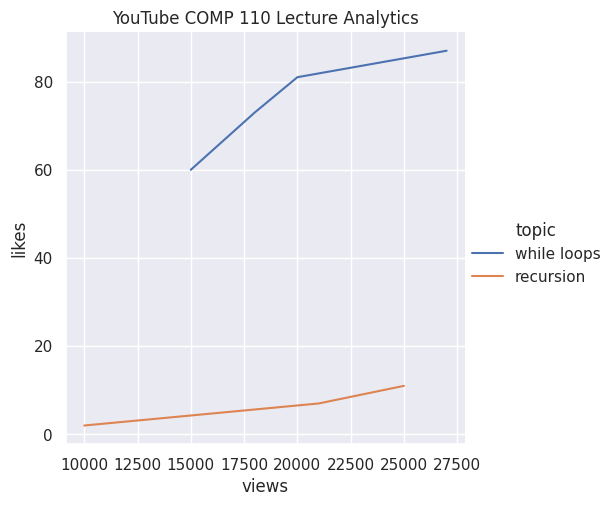

In [31]:
lineplot: sns.FacetGrid = sns.relplot(data=example_data_converted, kind="line", 
            x="views", y="likes", 
            hue="topic")

lineplot.set(title="YouTube COMP 110 Lecture Analytics")

## Part 1: Analysis for Continuous Improvement

Continuous Improvement embraces a belief there is _always room to make things better_. It is a mindset and process we value and practice in this course. In this assignment, you are able to practice continuous improvement and contribute to the design ideas of the course.

### Brainstorming Ideas

Reflect on your personal experiences and observations in COMP110 and **brainstorm modifications to the course that _create value_ beyond its current design**. When brainstorming, try not to be critical of the ideas you come up with regarding scale, stakeholders impacted, or for any other reasons. In the markdown cell below, brainstorm 3 to 5 ideas you think would create value for you.

Each brainstormed idea should state a. the suggested change or addition, b. what the expected value created, and c. which specific stakeholders would benefit.  If helpful, expand on the following template "The course should (state idea here) because it will (state value created here) for (insert stakeholders here)."

Example A: "The course should use only examples from psychology experiments because it will be more relevant for students who are psychology majors."

Example B: "The course should not have post-lesson questions because they are not useful for most students in the class."

### Part 1.1: Creative Ideation

1. "The course should have consistent recorded lectures because it will be helpful for quiz review for all students in the class."
2. "The course should release previous quizzes because it will mirror the actual exam for better review purposes for all students in the class."
3. "The course should provide examples of applications in other fields because it will emphasize practicality for students who are not computer science majors."
4. "The course should prioritize code writing over memory diagrams because it will provide practical experience for all students."
5. "The course should be more collaborative because it will foster an interdisciplinary learning environment for all students."

#### Connecting with Available Data

As a reminder, each row represents an individual survey response, and each column has a description which can be found on the project write-up here: <https://26s-comp110.github.io/exercises/ex09_data_analysis.html>

Review the list of available data and identify which one of your ideas _does not_, or is _least likely to_, have relevant data to support the analysis of your idea to create value. In the box below, identify which of your ideas lacks data and suggest how we might be able to collect this data in the future. One aspect of _continuous improvement_ is trying to avoid "tunnel vision" where possible improvements are not considered because there is no data available to analyze it. Identifying new data sources can unlock improvements!

### Part 1.2: Identifying Missing Data

1. Idea without sufficient data to analyze: Idea 2, "The course should release previous quizzes because it will mirror the actual exam for better review purposes for all students in the class."  

2. Suggestion for how to collect data to support this idea in the future: Provide future classes with previous quizzes and at the end of the semester ask if they were a helpful material in reviewing for quizzes.

#### Choosing an Idea to Analyze

Consider those of your ideas which _do_ seem likely to have relevant data to analyze. If none of your ideas do, spend a few minutes and brainstorm another idea or two with the added connection of data available on hand and add those ideas to your brainstormed ideas list.

Select the one idea which you believe is _most valuable_ to analyze relative to the others and has data to support the analysis of. In the markdown cell for Part 3 below, identify the idea you are exploring and articulate why you believe it is most valuable (e.g. widest impact, biggest opportunity for improvement, simplest change for significant improvement, and so on).

### Part 1.3: Choosing Your Analysis

1. Idea to analyze with available data: Idea 3, "The course should provide examples of applications in other fields because it will emphasize practicality for students who are not computer science majors."

2. This idea is more valuable than the others brainstormed because: There is direct data which can be analyzed to evaluate the value of this idea. 


#### Your Analysis

Before you begin analysis, a reminder that we do not expect the data to support everyone's ideas and you can complete this exercise for full credit even if the data does not clearly support your suggestion or even completely refutes it. What we are looking for is a logical attempt to explore the data using the techniques you have learned up until now in a way that _either_ supports, refutes, or does not have a clear result and then to reflect on your findings after the analysis.

Using the utility functions you created for the previous exercise, you will continue with your analysis in the following part. Before you begin, refer to the rubric on the technical expectations of this section in the exercise write-up.

In this section, you are expected to interleave code and markdown cells such that for each step of your analysis you are starting with an English description of what you are planning to do next in a markdown cell, followed by a Python cell that performs that step of the analysis.

Additionally, you will be producing charts or visualizations as part of your analysis via the Python package `seaborn`. Refer to the previous section on python packages and data visualization for more information on how to use this package and to the rubric for what will be required.

### Part 1.4: Analysis

Make sure to import your custom helper function in the code block below!

{'row': ['1', '2', '3', '4', '5'], 'year': ['27', '28', '29', '28', '28'], 'unc_status': ['Senior', 'Sophomore', 'Freshman', 'Sophomore', 'Sophomore'], 'transfer': ['No', 'Yes', 'No', 'No', 'No'], 'comp_major': ['No', 'No', 'No', 'No', 'No'], 'major': ['Chemistry', 'Economics', 'Statistics and Analytics', 'Psychology', 'Environmental Science/Studies'], 'prereqs': ['MATH 231, MATH 232, MATH 233, STOR 155', 'MATH 232, MATH 233', 'MATH 231', 'MATH 231, MATH 232, PSYC 210, STOR 155', 'MATH 129P, MATH 231, MATH 232, STOR 155'], 'prior_exp': ['None to less than one month!', '2-6 months', 'None to less than one month!', 'None to less than one month!', 'None to less than one month!'], 'ap_principles': ['', 'No', '', '', ''], 'ap_a': ['', 'No', '', '', ''], 'other_comp': ['', 'Another college or community college', '', '', ''], 'prior_time': ['', 'None to less than one month!', '', '', ''], 'languages': ['', 'Python', '', '', ''], 'hours_online_social': ['3 to 5 hours', '0 to 2 hours', '3 to 5 

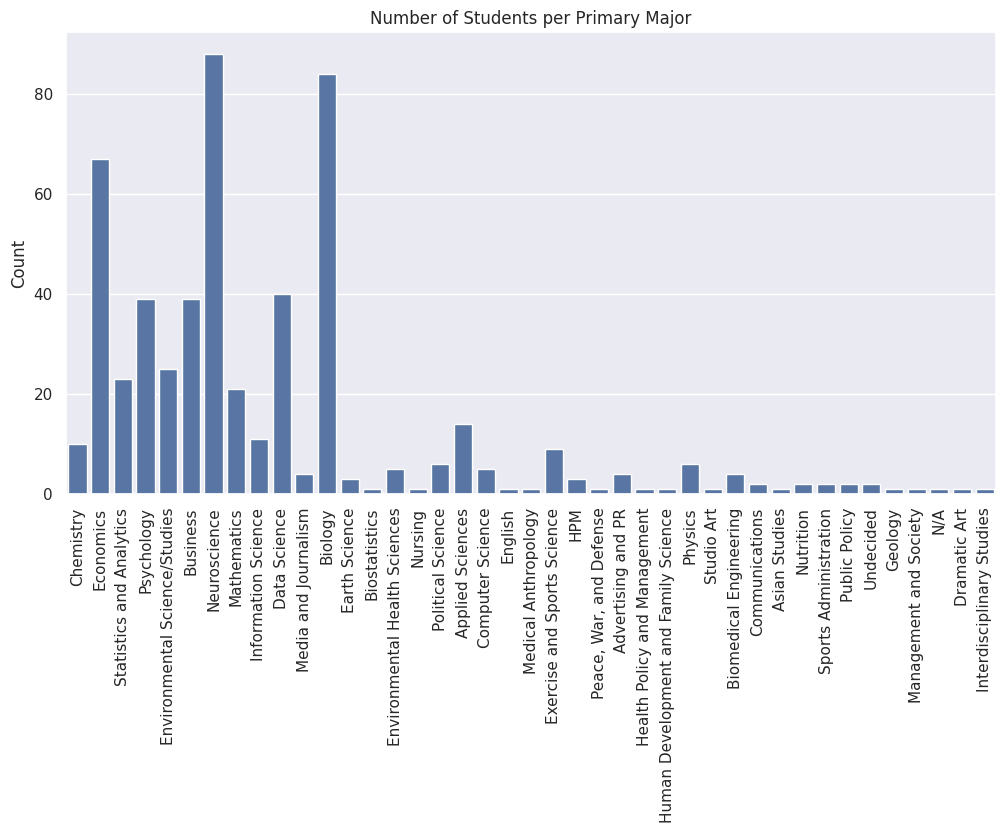

Non-CS students with high interest in connections: 112


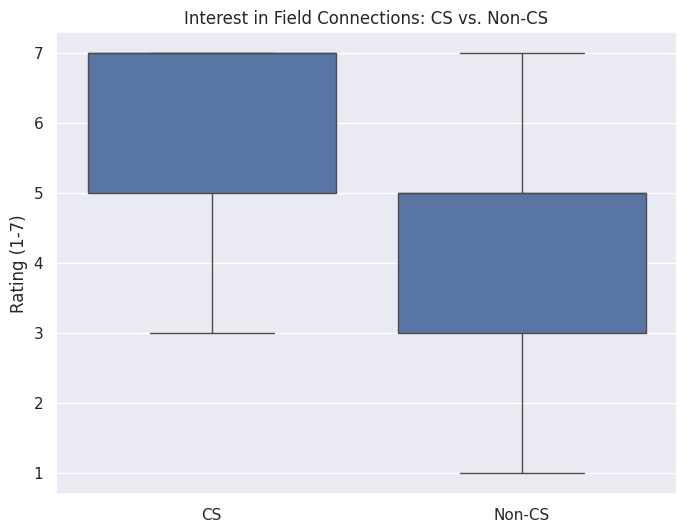

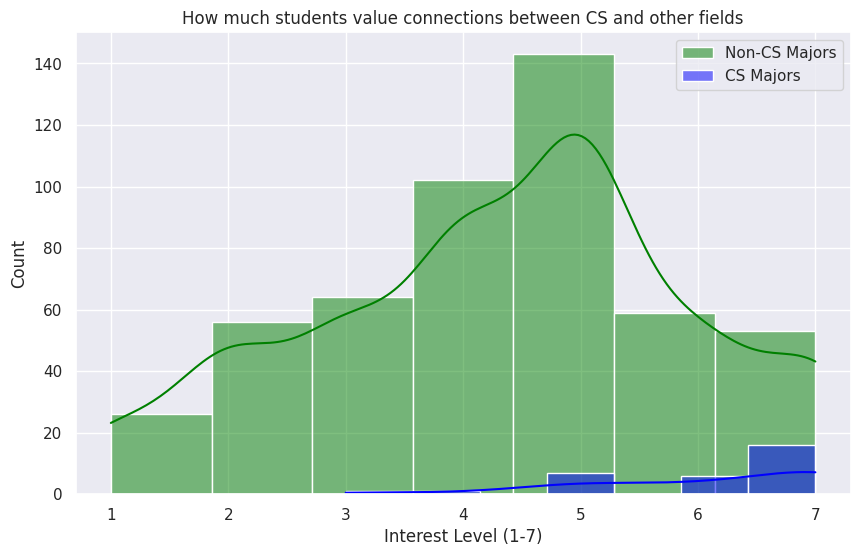

In [32]:
# TODO: You complete the code blocks from here onward!

import seaborn as sns
import matplotlib.pyplot as plt 
from data_utils import read_csv_rows, head, columnar, select, count 

def filter_above_threshold(values: list[float], threshold: float) -> list[float]:
    """Returns a list of values that are greater than the threshold."""
    filtered_list: list[float] = []
    for val in values:
        if val > threshold:
            filtered_list.append(val)
    return filtered_list 

# Load raw data from CSV file
data_rows: list[dict[str, str]] = read_csv_rows("data/survey_izzi.csv")

# Trasnform data to columnar format 
data_cols: dict[str, list[str]] = columnar(data_rows)

# View the first 5 rows of data
print(head(data_cols, 5))

# Select relevant columns for analysis
analysis_data: dict[str, list[str]] = select(data_cols, ["major", "interested_connections", "comp_major"])

# Use count utility to see major frequencies 
major_counts: dict[str, int] = count(analysis_data["major"])
print(f"Frequency of majors: {major_counts}")

# Visualization 1, Bar Chart: Distribution of Majors
plt.figure(figsize=(12, 6))
sns.barplot(x=list(major_counts.keys()), y=list(major_counts.values()))
plt.title("Number of Students per Primary Major")
plt.xticks(rotation=90) 
plt.ylabel("Count")
plt.show() 

# Separate into CS and Non-CS groups
cs_conn_interest: list[float] = []
non_cs_conn_interest: list[float] = []

for i in range(len(analysis_data["major"])):
    # Check for empty strings
    if analysis_data["interested_connections"][i] != "":
        interest_val = float(analysis_data["interested_connections"][i])
        if analysis_data["comp_major"][i] == "No":
            non_cs_conn_interest.append(interest_val)
        else:
            cs_conn_interest.append(interest_val)

# Use custom helper function
high_conn_interest_non_cs = filter_above_threshold(non_cs_conn_interest, 5.0) 
print(f"Non-CS students with high interest in connections: {len(high_conn_interest_non_cs)}")

# Visualization 2, Box Plot: Connection Interest Comparison
labels = ["CS"] * len(cs_conn_interest) + ["Non-CS"] * len(non_cs_conn_interest)
combined_interests = cs_conn_interest + non_cs_conn_interest

plt.figure(figsize=(8, 6))
sns.boxplot(x=labels, y=combined_interests)
plt.title("Interest in Field Connections: CS vs. Non-CS")
plt.ylabel("Rating (1-7)")
plt.show() 

# Visualization 3, Histogram: Density of Interest in Connections
plt.figure(figsize=(10, 6))
sns.histplot(non_cs_conn_interest, color = "green", label = "Non-CS Majors", kde=True, bins=7)
sns.histplot(cs_conn_interest, color = "blue", label="CS Majors", kde=True, bins=7)
plt.title("How much students value connections between CS and other fields")
plt.xlabel("Interest Level (1-7)")
plt.legend()
plt.show() 

Next, ... (you take it from here and add additional code and markdown cells as needed)

#### Conclusion

In the following markdown cell, write a reflective conclusion given the analysis you performed and identify recommendations.

If your analysis of the data supports your idea, state your recommendation for the change and summarize the data analysixs results you found which support it. Additionally, describe any extensions or refinements to this idea which might be explored further. Finally, discuss the potential costs, trade-offs, or stakeholders who may be negatively impacted by this proposed change.

If your analysis of the data is inconclusive, summarize why your data analysis results were inconclusive in the support of your idea. Additionally, describe what experimental idea implementation or additional data collection might help build more confidence in assessing your idea. Finally, discuss the potential costs, trade-offs, or stakeholders who may be negatively impacted by experimenting with your idea.

Finally, if your analysis of the data does not support it, summarize your data analysis results and why it refutes your idea. Discuss the potential costs, trade-offs, or stakeholders who may be negatively impacted by this proposed change. If you disagree with the validity of the findings, describe why your idea still makes sense to implement and what alternative data would better support it. If you agree with the validity of the data analysis, describe what alternate ideas or extensions you would explore instead. 

### Part 1.5: Conclusion



Based on the analysis of the COMP110 survey data (specifically survey_izzi), our idea that the course should provide examples of applications in other fields to support learning is strongly supported by the data.

The analysis shows a high level of interest in the connections between computer science and other fields across all students. 

Both Computer Science majors and Non-CS majors reported high scores in the interested_connections column, a significant number of students providing ratings of 4-7. 

The primary_major distribution showed a very large variety of academic backgrounds (Biology, Economics, Psychology, Media/Journalism, etc.). The box plot also indicated that Non-CS majors had an average belief in connecting different fields while CS majors have a high interest. 

We recommend that in the future, the course can try to include at least one interdisciplinary example into each major module. For example, instead of focusing on purely tech-focused examples, the course could use a dataset from public policy or neuroscience. The course could also implement having a "select your coding exercise" where the programming logic is the same, but students can choose a "theme" (healthcare, finance, etc.) so that the information is most relevant to them. 

This change does have some potential costs as creating these examples requires more time and effort from instructors and TAs both to integrate and confirm. Adding in different field examples could also confuse some students, making things more complicated. 

However, ultimately, with the large number of non-CS majors taking this course, we think that it would be helpful to integrate our suggestion so that the course is more engaging and practical. 

## Part 2: Presenting Your Results

Follow the instructions [linked here](https://comp110-26s.github.io/projects/personal-site.html) to set up your website, and refer to the rubric in the project write-up for what will be required!

Once you are finished, put the links (for each partner) to each of your project pages below. We will only be grading the first link given according to the rubric, but make sure the second link works and looks similar to the first.

First link: https://sshloka.github.io/ex09/ 

Second link: https://sanjalav.github.io/ex09/ 